# Predictive Horizon Sweep
At what point in the growing season can you predict harvest-window NDVI anomaly?
Trains a RF model using only features available up to each cutoff week (terrain + soil + climate + NDVI slope/std ≤ cutoff).
Uses RF only (not full stack) for tractable runtime across 6 cutoffs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

os.makedirs('../img', exist_ok=True)

In [2]:
# --- Load data and build full clean feature set ---
df = pd.read_pickle('../data/df.pkl')
target_cols = [f'ndvi_anomaly_{w}' for w in range(36, 44)]

leakage_cols = []
leakage_cols += [col for col in df.columns if col.startswith('ndvi_smooth_mean') and any(col.endswith(f'_{m}') for m in range(36, 45))]
leakage_cols += [col for col in df.columns if col.startswith('ndvi_smooth_mean') and col not in leakage_cols]
leakage_cols += [col for col in df.columns if (col.startswith('ndvi_smooth_slope_') or col.startswith('ndvi_smooth_std_')) and int(col.rsplit('_', 1)[-1]) >= 36]
leakage_cols += [c for c in ['ndvi_mean','ndvi_cov','ndvi_std','ndvi_mean_norm','ndvi_std_norm','ndvi_cov_norm','health'] if c in df.columns]
leakage_cols += [col for col in df.columns if 'mcari2' in col or 'rendvi' in col]
leakage_cols += [col for col in df.columns if col.endswith('length')]

drop_cols = set(leakage_cols + ['plot_id', 'year'] + target_cols)
X_full = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df[target_cols]

# Identify static feature groups (non-NDVI: always included)
all_ndvi_cols = [c for c in X_full.columns if c.startswith('ndvi_smooth_slope_') or c.startswith('ndvi_smooth_std_')]
static_cols = [c for c in X_full.columns if c not in all_ndvi_cols]
print(f'Static features (terrain+soil+climate): {len(static_cols)}')
print(f'Early-season NDVI cols (wks 1-35): {len(all_ndvi_cols)}')

X_train_full, X_tune, y_train_full, y_tune = train_test_split(X_full, y, test_size=0.2, random_state=42)
X_train_full, X_test, y_train_full, y_test = train_test_split(X_train_full, y_train_full, test_size=0.15, random_state=42)

Static features (terrain+soil+climate): 213
Early-season NDVI cols (wks 1-35): 70


In [3]:
def make_pipeline(feature_cols):
    numeric_features = X_full[feature_cols].select_dtypes(include=['float64','int64']).columns.tolist()
    preprocessor = ColumnTransformer(
        [('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('scl', StandardScaler())]), numeric_features)],
        remainder='drop'
    )
    rf = RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1)
    return Pipeline([('preprocessor', preprocessor), ('regressor', MultiOutputRegressor(rf, n_jobs=-1))])


cutoffs = [10, 15, 20, 25, 30, 35]
results = []

for cutoff in cutoffs:
    # Features available up to this week: static + NDVI slope/std for weeks <= cutoff
    ndvi_at_cutoff = [c for c in all_ndvi_cols if int(c.rsplit('_', 1)[-1]) <= cutoff]
    feature_cols = static_cols + ndvi_at_cutoff

    pipe = make_pipeline(feature_cols)
    pipe.fit(X_train_full[feature_cols], y_train_full)
    y_pred = pipe.predict(X_test[feature_cols])
    r2 = r2_score(y_test, y_pred)

    per_week = [r2_score(y_test.iloc[:, i], y_pred[:, i]) for i in range(8)]
    results.append({'cutoff': cutoff, 'r2': r2, 'n_features': len(feature_cols), 'per_week': per_week})
    print(f'Week ≤ {cutoff:2d} | features={len(feature_cols):3d} | R²={r2:.4f}')

# Also run with no NDVI (static only baseline)
pipe_static = make_pipeline(static_cols)
pipe_static.fit(X_train_full[static_cols], y_train_full)
y_pred_static = pipe_static.predict(X_test[static_cols])
r2_static = r2_score(y_test, y_pred_static)
print(f'Static only    | features={len(static_cols):3d} | R²={r2_static:.4f}')

Week ≤ 10 | features=233 | R²=0.6384
Week ≤ 15 | features=243 | R²=0.6729
Week ≤ 20 | features=253 | R²=0.7356
Week ≤ 25 | features=263 | R²=0.7804
Week ≤ 30 | features=273 | R²=0.7819
Week ≤ 35 | features=283 | R²=0.8067
Static only    | features=213 | R²=0.6094


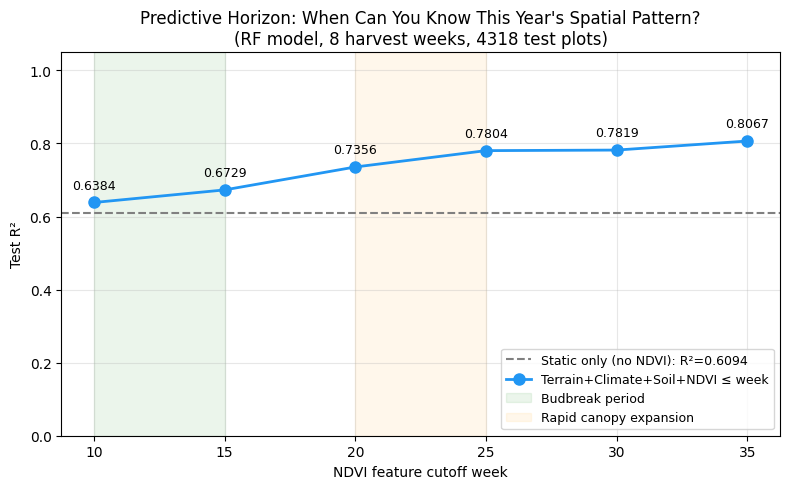

In [4]:
# --- Plot: R² vs cutoff week ---
cutoff_vals = [r['cutoff'] for r in results]
r2_vals = [r['r2'] for r in results]

fig, ax = plt.subplots(figsize=(8, 5))
ax.axhline(r2_static, color='gray', linestyle='--', linewidth=1.5, label=f'Static only (no NDVI): R²={r2_static:.4f}')
ax.plot(cutoff_vals, r2_vals, 'o-', color='#2196F3', linewidth=2, markersize=8, label='Terrain+Climate+Soil+NDVI ≤ week')

for cutoff, r2 in zip(cutoff_vals, r2_vals):
    ax.annotate(f'{r2:.4f}', (cutoff, r2), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)

# Annotate key phenological events
ax.axvspan(10, 15, alpha=0.08, color='green', label='Budbreak period')
ax.axvspan(20, 25, alpha=0.08, color='orange', label='Rapid canopy expansion')

ax.set_xlabel('NDVI feature cutoff week')
ax.set_ylabel('Test R²')
ax.set_title('Predictive Horizon: When Can You Know This Year\'s Spatial Pattern?\n(RF model, 8 harvest weeks, 4318 test plots)')
ax.set_xticks(cutoff_vals)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../img/horizon_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

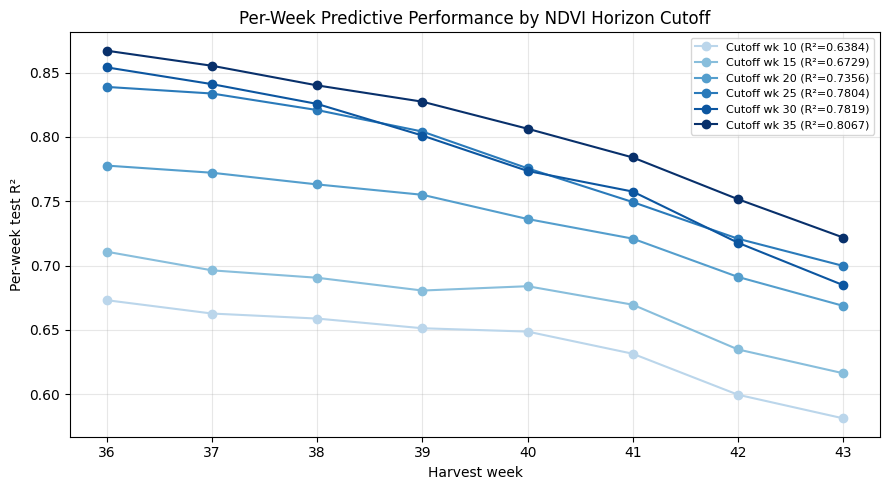

In [5]:
# --- Per-week R² across cutoffs ---
weeks = list(range(36, 44))
cmap = plt.colormaps['Blues'].resampled(len(cutoffs) + 2)

fig, ax = plt.subplots(figsize=(9, 5))
for i, r in enumerate(results):
    ax.plot(weeks, r['per_week'], 'o-', color=cmap(i + 2), linewidth=1.5,
            label=f'Cutoff wk {r["cutoff"]} (R²={r["r2"]:.4f})', markersize=6)

ax.set_xlabel('Harvest week')
ax.set_ylabel('Per-week test R²')
ax.set_title('Per-Week Predictive Performance by NDVI Horizon Cutoff')
ax.set_xticks(weeks)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../img/horizon_per_week.png', dpi=150, bbox_inches='tight')
plt.show()